In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from sklearn.preprocessing import MinMaxScaler
import math as ma
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

In [2]:
connect = sqlite3.connect("C:/Forge/Python/database.db")
df = pd.read_sql('SELECT * FROM weather5', connect)
connect.close()

def get_label_list(df, flag_print):
    label_list = df.columns.tolist() 
    for i in range(len(label_list)):
        df[label_list[i]] = pd.to_numeric(df[label_list[i]], errors='coerce') # заменяем пропуски на NaN
        if (flag_print):
            print(i, "/", i - len(label_list), ": ", label_list[i], sep="", end="  ")
    return label_list

label_list = get_label_list(df, 1)

for i in range(len(label_list)):
    df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)

df = df.drop(['id', 'max_temp', 'min_temp', 'precipit', 'norm_plus'], axis=1)
df = df.dropna()

df.head(-1)

0/-9: id  1/-8: year  2/-7: month  3/-6: day  4/-5: max_temp  5/-4: sr_temp  6/-3: min_temp  7/-2: precipit  8/-1: norm_plus  

,year,month,day,sr_temp
0,1881,1,1,-0.2
1,1881,1,2,-1.1
2,1881,1,3,1.1
3,1881,1,4,1.7
4,1881,1,5,-6.1
...,...,...,...,...
53297,2026,8,15,16.1
53298,2026,8,16,18.1
53299,2026,8,17,17.1
53300,2026,8,18,16.8


In [3]:
def build_week_windows(df, pred_day_end, temp_col='sr_temp'):
    df = df.reset_index(drop=True)
    n = len(df)
    window_size = pred_day_end + 1

    chunks = []
    for x in range(n - window_size + 1):
        window = df.iloc[x : x + window_size].copy()
        window['begin_temp'] = df.iloc[x][temp_col]
        window['number_day_pred'] = np.arange(window_size)
        chunks.append(window)

    return pd.concat(chunks, ignore_index=True)

df = build_week_windows(df, pred_day_end=7)

In [4]:
df['sr_temp'] = df['sr_temp']

df = df.dropna()

label_list = get_label_list(df, 0)

days_in_month_1 = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце не весокостного года
days_in_month_2 = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце весокостного года

def day_of_year(x):                                                          #
    if x['year'] % 400 == 0 or x['year'] % 4 == 0 and x['year'] % 100 != 0:  #                   
        y = sum(days_in_month_2[:int(x['month'])-1]) + int(x['day'])         # функция возвращающая радиану номера дня в году с помощью метода Мин-Макс масштабирования
        l = 366                                                              #
    else:                                                                    #
        y = sum(days_in_month_1[:int(x['month'])-1]) + int(x['day'])         #    
        l = 365                                                              #
    return (y - 1) / (l - 1)                                                 #

def day_degree(x):
    if x['year'] % 400 == 0 or x['year'] % 4 == 0 and x['year'] % 100 != 0: 
        day_m = days_in_month_2       
    else:                                                                        
        day_m = days_in_month_1
    return (x['day'] - 1) / (day_m[int(x['month'])-1] - 1)

df['day_of_year'] = df[['year', 'month', 'day']].apply(day_of_year, axis=1)

scal = MinMaxScaler()
df['month_degree'] = scal.fit_transform(df[['month']]) * 2 * ma.pi   # преобразуем номер месяца в соответствующее количество радиан, где 12-ый месяц = 6.28 радиан
df['day_degree'] = df[['day', 'year', 'month']].apply(day_degree, axis=1) * 2 * ma.pi        # преобразуем номер дня в месяце в соответствующее количество радиан, где последний день месяца = 6.28 радиан
df['day_of_year'] = df['day_of_year'] * 2 * ma.pi    # преобразуем номер дня в году в соответствующее количество радиан, где 365 день = 6.28 радиан
def set_rad_cos(x):
    return ma.cos(x)
def set_rad_sin(x):
    return ma.sin(x)

df['month_cos'] = df['month_degree'].apply(set_rad_cos)
df['month_sin'] = df['month_degree'].apply(set_rad_sin)

df['day_cos'] = df['day_degree'].apply(set_rad_cos)
df['day_sin'] = df['day_degree'].apply(set_rad_sin)

df['day_of_year_cos'] = df['day_of_year'].apply(set_rad_cos)
df['day_of_year_sin'] = df['day_of_year'].apply(set_rad_sin)


df = df.drop(['month_degree', 'day_degree'], axis=1)         # убираем все ненужные колонки датасета

label_list = get_label_list(df, 1)
print()
df.head(20)

0/-13: year  1/-12: month  2/-11: day  3/-10: sr_temp  4/-9: begin_temp  5/-8: number_day_pred  6/-7: day_of_year  7/-6: month_cos  8/-5: month_sin  9/-4: day_cos  10/-3: day_sin  11/-2: day_of_year_cos  12/-1: day_of_year_sin  


,year,month,day,sr_temp,begin_temp,number_day_pred,day_of_year,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin
0,1881,1,1,-0.2,-0.2,0,0.000000,1.0,0.0,1.000000,0.000000,1.000000,0.000000
1,1881,1,2,-1.1,-0.2,1,0.017261,1.0,0.0,0.978148,0.207912,0.999851,0.017261
2,1881,1,3,1.1,-0.2,2,0.034523,1.0,0.0,0.913545,0.406737,0.999404,0.034516
3,1881,1,4,1.7,-0.2,3,0.051784,1.0,0.0,0.809017,0.587785,0.998659,0.051761
4,1881,1,5,-6.1,-0.2,4,0.069046,1.0,0.0,0.669131,0.743145,0.997617,0.068991
5,1881,1,6,-7.6,-0.2,5,0.086307,1.0,0.0,0.500000,0.866025,0.996278,0.086200
6,1881,1,7,-5.5,-0.2,6,0.103569,1.0,0.0,0.309017,0.951057,0.994642,0.103384
7,1881,1,8,-10.8,-0.2,7,0.120830,1.0,0.0,0.104528,0.994522,0.992709,0.120537
8,1881,1,2,-1.1,-1.1,0,0.017261,1.0,0.0,0.978148,0.207912,0.999851,0.017261
9,1881,1,3,1.1,-1.1,1,0.034523,1.0,0.0,0.913545,0.406737,0.999404,0.034516


In [5]:
predict_day_num = 8
date = {'year': 2025, 'month': 6, 'day': 19}
mask = (
    (df['year'] > date['year']) & (df['number_day_pred'] == 0) |
    ((df['year'] == date['year']) & (df['month'] > date['month'])) & (df['number_day_pred'] == 0) |
    (
        (df['year'] == date['year']) &
        (df['month'] == date['month']) &
        (df['day'] >= date['day']) & (df['number_day_pred'] == 0)
    )
)
df_after = df[mask].copy()
df_after = pd.DataFrame(df_after.iloc[:predict_day_num+1, :])
mask = (
    (df['year'] < date['year']) |
    ((df['year'] == date['year']) & (df['month'] < date['month'])) |
    (
        (df['year'] == date['year']) &
        (df['month'] == date['month']) &
        (df['day'] <= date['day'])
    )
)

df = df[mask]

predict_num = 3
un_test_numbers_Xboost = [predict_num, 13, 14, 15, 16, 17, 18, 19]
un_test_numbers_LinReg = [predict_num, 13, 14, 15, 16, 17, 18, 19]
un_test_numbers_RForest = [predict_num,]

model_Xb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model_Rf = RandomForestRegressor(max_depth=20, max_features=5)

x = pd.DataFrame(df.copy().iloc[:, [i for i in range(len(label_list)) if (i not in [predict_num])]])
y = pd.DataFrame(df.copy().iloc[:, [1]])
l = get_label_list(df, 1)

0/-13: year  1/-12: month  2/-11: day  3/-10: sr_temp  4/-9: begin_temp  5/-8: number_day_pred  6/-7: day_of_year  7/-6: month_cos  8/-5: month_sin  9/-4: day_cos  10/-3: day_sin  11/-2: day_of_year_cos  12/-1: day_of_year_sin  

In [6]:
print(len(df))
drop_numer = 2
for i in range(3, 20):
    if len(df) % i == 0:
        drop_numer = i
        break

df_predict = pd.DataFrame({'Predicted': np.nan}, index=df.index)
naget = len(df) // drop_numer
print("XGBRegressor")
print('Набор данных будет обработан в', drop_numer, "шага(ов).")
for i in range(drop_numer):
    df_naget = df.iloc[i*(naget): (i+1)*(naget)]
    df_unnaget = df.drop(df_naget.index)
    print(f'Обработано {(i+1)*(naget)} из {len(df)}')

    label_list = get_label_list(df_naget, 0)

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_LinReg)]

    x_train, x_test = df_unnaget.iloc[:, label_number_list], df_naget.iloc[:,label_number_list]
    y_train, y_test = df_unnaget.iloc[:, predict_num], df_naget.iloc[:, predict_num]

    model = model_Xb
    model.fit(x_train, y_train)
    y_pred_test = model.predict(x_test)

    df_predict.loc[df_naget.index, 'Predicted'] = y_pred_test.ravel()

df['Predicted'] = df_predict['Predicted']
df['Predicted-temp'] = df_predict['Predicted'] - df['sr_temp'].shift(1)

df_predict = pd.DataFrame({'Predicted2': np.nan}, index=df.index)
print("LinearRegression")
for i in range(drop_numer):
    df_naget = df.iloc[i*(naget): (i+1)*(naget)]
    df_unnaget = df.drop(df_naget.index)
    print(f'Обработано {(i+1)*(naget)} из {len(df)}')

    label_list = get_label_list(df_naget, 0)

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_LinReg)]

    x_train, x_test = df_unnaget.iloc[:, label_number_list], df_naget.iloc[:,label_number_list]
    y_train, y_test = df_unnaget.iloc[:, predict_num], df_naget.iloc[:, predict_num]

    model = LinearRegression()
    model.fit(x_train, y_train)
    y_pred_test = model.predict(x_test)

    df_predict.loc[df_naget.index, 'Predicted2'] = y_pred_test.ravel()

df['Predicted2'] = df_predict['Predicted2']
df['Predicted2-temp'] = df_predict['Predicted2'] - df['sr_temp'].shift(1)

df['Predicted_ras'] = df['Predicted'] - df['Predicted2']
df['Predicted_mean'] = (df['Predicted'] + df['Predicted2']) / 2

df = df.dropna()
get_label_list(df, 1)
df.head(1)

422092
XGBRegressor
Набор данных будет обработан в 4 шага(ов).
Обработано 105523 из 422092
Обработано 211046 из 422092
Обработано 316569 из 422092
Обработано 422092 из 422092
LinearRegression
Обработано 105523 из 422092
Обработано 211046 из 422092
Обработано 316569 из 422092
Обработано 422092 из 422092
0/-19: year  1/-18: month  2/-17: day  3/-16: sr_temp  4/-15: begin_temp  5/-14: number_day_pred  6/-13: day_of_year  7/-12: month_cos  8/-11: month_sin  9/-10: day_cos  10/-9: day_sin  11/-8: day_of_year_cos  12/-7: day_of_year_sin  13/-6: Predicted  14/-5: Predicted-temp  15/-4: Predicted2  16/-3: Predicted2-temp  17/-2: Predicted_ras  18/-1: Predicted_mean  

,year,month,day,sr_temp,begin_temp,number_day_pred,day_of_year,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted-temp,Predicted2,Predicted2-temp,Predicted_ras,Predicted_mean
1,1881,1,2,-1.1,-0.2,1,0.017261,1.0,0.0,0.978148,0.207912,0.999851,0.017261,-3.139479,-2.939479,-4.476727,-4.276727,1.337248,-3.808103


XBoost:
       year  month       day  begin_temp  number_day_pred  day_of_year  \
0  0.003321    0.0  0.000095     0.81214         0.005908     0.014034   

   month_cos  month_sin   day_cos   day_sin  day_of_year_cos  day_of_year_sin  
0   0.000002    0.00023  0.000023  0.000106         0.146676         0.017463  
------------------------


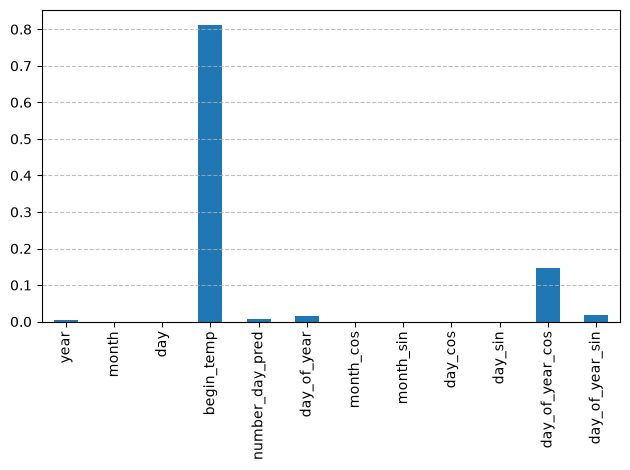

LinReg:
       year     month       day  begin_temp  number_day_pred  day_of_year  \
0  0.009022  1.084927  0.037152    0.528426         0.000141    -2.009491   

   month_cos  month_sin  day_cos   day_sin  day_of_year_cos  day_of_year_sin  
0  -0.536279   0.334405  0.07107  0.023164        -5.246086        -1.817852  
------------------------


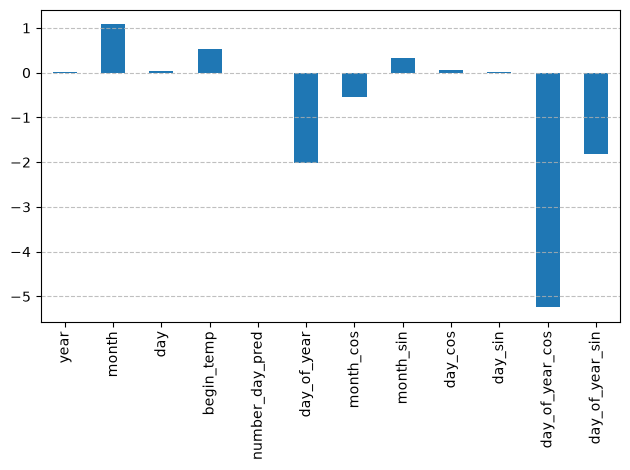

RForest:
       year     month       day  begin_temp  number_day_pred  day_of_year  \
0  0.004775  0.012043  0.002089    0.079651         0.014526     0.018908   

   month_cos  month_sin   day_cos   day_sin  day_of_year_cos  day_of_year_sin  \
0   0.037013   0.001565  0.002137  0.002223         0.046297         0.005113   

   Predicted  Predicted-temp  Predicted2  Predicted2-temp  Predicted_ras  \
0   0.334454        0.034107    0.184931         0.041838       0.004716   

   Predicted_mean  
0        0.173612  
------------------------


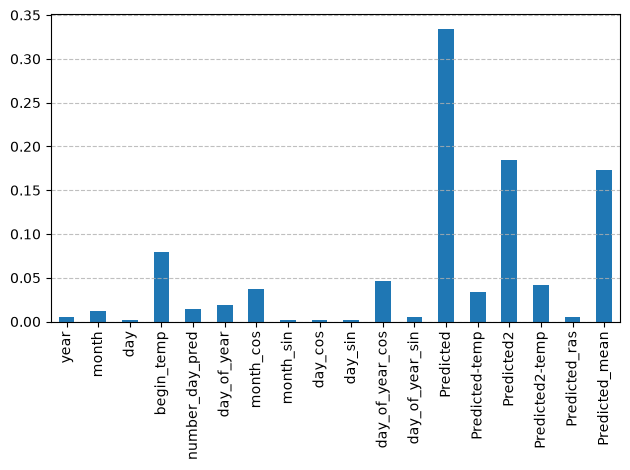

In [7]:
label_list = pd.DataFrame(df).columns.tolist()
label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_Xboost)]
x_train = df.iloc[:, label_number_list]
y_train = df.iloc[:, predict_num]

model_Xboost = model_Xb
model_Xboost.fit(x_train, y_train)

label_list = pd.DataFrame(x_train).columns.tolist()
m = model_Xboost.feature_importances_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(pd.DataFrame(x_train).columns.tolist())):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]

print('XBoost:')
print(cof)
df_tail = df_naget.dropna()
print("------------------------")
coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model_Xboost.feature_importances_]})
cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

label_list = pd.DataFrame(df).columns.tolist()
label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_LinReg)]
x_train = df.iloc[:, label_number_list]
y_train = df.iloc[:, predict_num]

model_LinReg = LinearRegression()
model_LinReg.fit(x_train, y_train)

label_list = pd.DataFrame(x_train).columns.tolist()
m = model_LinReg.coef_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(pd.DataFrame(x_train).columns.tolist())):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]

print('LinReg:')
print(cof)
df_tail = df_naget.dropna()
print("------------------------")
coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model_LinReg.coef_]})
cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

label_list = pd.DataFrame(df).columns.tolist()
label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_RForest)]
x_train = df.iloc[:, label_number_list]
y_train = df.iloc[:, predict_num]

model_RForest = model_Rf
model_RForest.fit(x_train,y_train)

label_list = pd.DataFrame(x_train).columns.tolist()
m = model_RForest.feature_importances_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(pd.DataFrame(x_train).columns.tolist())):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]

print('RForest:')
print(cof)
df_tail = df_naget.dropna()
print("------------------------")
coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model_RForest.feature_importances_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()
        

In [8]:
df_new = pd.DataFrame(df.tail(1))
df_new = df_new.reset_index(drop=True)

year, month, day = date['year'], date['month'], date['day']

if year == 400 or year % 4 == 0 and year % 100 != 0:         
    month_list_day = days_in_month_2   
    day_in_year = 366    
else:                                                                       
    month_list_day = days_in_month_1
    day_in_year = 365

begin_temp = df_new.tail(1)['sr_temp'][0]
last_temp = begin_temp

df_new.at[0, 'Predicted'] = begin_temp
df_new.at[0, 'Predicted2'] = begin_temp
df_new.at[0, 'Predicted_mean'] = begin_temp

df_new.head(1)

,year,month,day,sr_temp,begin_temp,number_day_pred,day_of_year,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted-temp,Predicted2,Predicted2-temp,Predicted_ras,Predicted_mean
0,2025,6,19,14.2,14.2,0,2.917193,-0.959493,0.281733,-0.725995,-0.687699,-0.974928,0.222521,14.2,1.856817,14.2,1.287973,0.568844,14.2


In [9]:
label_list = pd.DataFrame(df_new).columns.tolist()
for iter in range(1, predict_day_num+1):
    day+=1 
    if day > month_list_day[int(month)-1]:
        month += 1   
        day = 1     
    if month > 12:
        month = 1
        year += 1
    if year == 400 or year % 4 == 0 and year % 100 != 0:         
        month_list_day = days_in_month_2   
        day_in_year = 366    
    else:                                                                       
        month_list_day = days_in_month_1
        day_in_year = 365

    df_new.at[iter, 'year'] = year
    df_new.at[iter, 'month'] = month
    df_new.at[iter, 'day'] = day
    df_new.at[iter, 'number_day_pred'] = iter
    df_new.at[iter, 'begin_temp'] = begin_temp

    def day_of_year(y, m, d):                                                                                                                                        
        if y % 400 == 0 or y % 4 == 0 and y % 100 != 0:         
            return sum(days_in_month_2[:int(m)-1]) + int(d)        
        else:                                                                       
            return sum(days_in_month_1[:int(m)-1]) + int(d)                                                                         
    
    day_of_year_n = day_of_year(year, month, day)

    def min_max(x, xmin, xmax):
        return (x - xmin) / (xmax - xmin)

    month_degree = min_max(month, 1, 12) * 2 * ma.pi   
    day_degree = min_max(day, 1, month_list_day[int(month)-1]) * 2 * ma.pi       
    day_of_year_n_degree = min_max(day_of_year_n, 1, day_in_year) * 2 * ma.pi    

    def set_rad_cos(x):
        return ma.cos(x)
    def set_rad_sin(x):
        return ma.sin(x)

    month_cos = set_rad_cos(month_degree)
    month_sin = set_rad_sin(month_degree)
    day_cos = set_rad_cos(day_degree)
    day_sin = set_rad_sin(day_degree)
    day_of_year_cos = set_rad_cos(day_of_year_n_degree)
    day_of_year_sin = set_rad_sin(day_of_year_n_degree)

    df_new.at[iter, 'day_of_year'] = day_of_year_n_degree
    df_new.at[iter, 'month_cos'] = month_cos
    df_new.at[iter, 'month_sin'] = month_sin
    df_new.at[iter, 'day_cos'] = day_cos
    df_new.at[iter, 'day_sin'] = day_sin
    df_new.at[iter, 'day_of_year_cos'] = day_of_year_cos
    df_new.at[iter, 'day_of_year_sin'] = day_of_year_sin

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_Xboost)]
    x_train = df_new.iloc[[-1], label_number_list]
    predict_n = model_Xboost.predict(x_train)[0]
    df_new.at[iter, 'Predicted'] = predict_n
    first_predict = predict_n
    df_new.at[iter, 'Predicted-temp'] = predict_n - last_temp

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_LinReg)]
    x_train = df_new.iloc[[-1], label_number_list]
    
    predict_n = model_LinReg.predict(x_train)
    df_new.at[iter, 'Predicted2'] = predict_n[0]
    df_new.at[iter, 'Predicted2-temp'] = predict_n[0] - last_temp

    df_new.at[iter, 'Predicted_ras'] = first_predict - predict_n[0]
    df_new.at[iter, 'Predicted_mean'] = (first_predict + predict_n[0]) / 2

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_RForest)]
    x_train = df_new.iloc[[-1], label_number_list]
    last_temp = model_RForest.predict(x_train)[0]
    df_new.at[iter, 'Predicted3'] = last_temp
    df_new.at[iter, 'sr_temp'] = last_temp


df_new.head(-1)

,year,month,day,sr_temp,begin_temp,number_day_pred,day_of_year,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted-temp,Predicted2,Predicted2-temp,Predicted_ras,Predicted_mean,Predicted3
0,2025.0,6.0,19.0,14.200000,14.2,0.0,2.917193,-0.959493,0.281733,-0.725995,-0.687699,-0.974928,0.222521,14.200000,1.856817,14.200000,1.287973,0.568844,14.200000,NaN
1,2025.0,6.0,20.0,14.720749,14.2,1.0,2.934455,-0.959493,0.281733,-0.561187,-0.827689,-0.978624,0.205660,16.438615,2.238615,15.919286,1.719286,0.519329,16.178950,14.720749
2,2025.0,6.0,21.0,15.153066,14.2,2.0,2.951716,-0.959493,0.281733,-0.370138,-0.928977,-0.982028,0.188738,16.472719,1.751970,15.981744,1.260995,0.490976,16.227231,15.153066
3,2025.0,6.0,22.0,15.624487,14.2,3.0,2.968978,-0.959493,0.281733,-0.161782,-0.986827,-0.985139,0.171759,16.831939,1.678873,16.045005,0.891939,0.786934,16.438472,15.624487
4,2025.0,6.0,23.0,16.167365,14.2,4.0,2.986239,-0.959493,0.281733,0.054139,-0.998533,-0.987957,0.154729,17.041381,1.416894,16.108426,0.483939,0.932955,16.574903,16.167365
5,2025.0,6.0,24.0,16.377339,14.2,5.0,3.003501,-0.959493,0.281733,0.267528,-0.963550,-0.990480,0.137654,17.041381,0.874016,16.171288,0.003923,0.870093,16.606335,16.377339
6,2025.0,6.0,25.0,16.453824,14.2,6.0,3.020762,-0.959493,0.281733,0.468408,-0.883512,-0.992709,0.120537,17.132953,0.755615,16.232831,-0.144507,0.900122,16.682892,16.453824
7,2025.0,6.0,26.0,16.624739,14.2,7.0,3.038024,-0.959493,0.281733,0.647386,-0.762162,-0.994642,0.103384,17.225280,0.771456,16.292289,-0.161535,0.932991,16.758784,16.624739


Самый значимый признак: Predicted


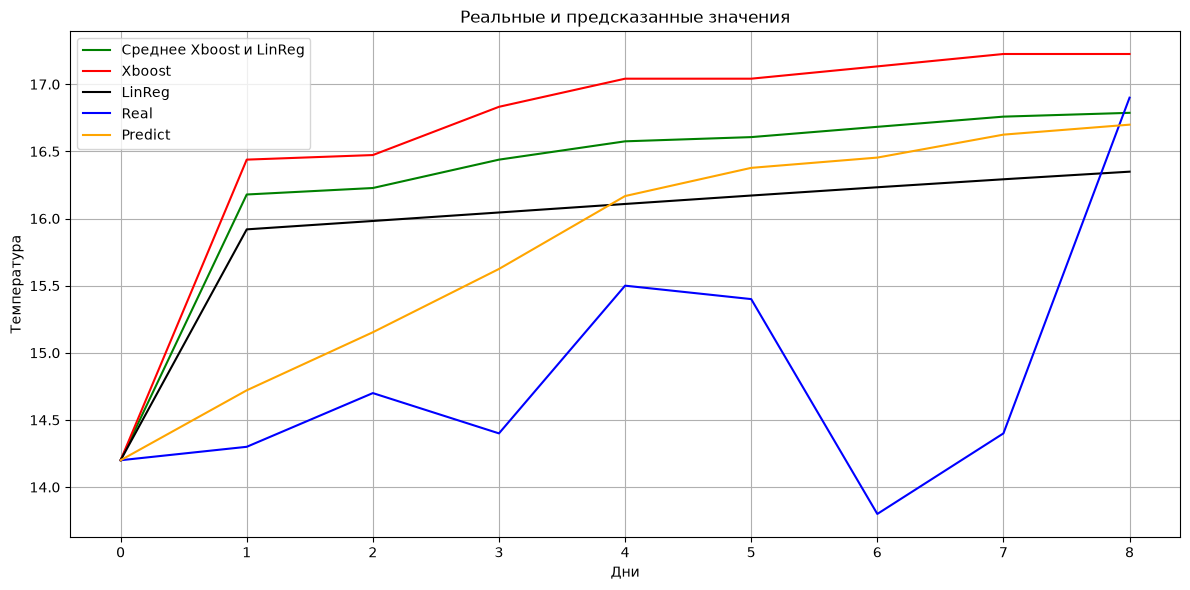

------------------------
RandFores:
# MAE и MSE по тестовой выборке
Test MSE:  1.7016526444857287
Test MAE:  0.9802843510884691
------------------------
R^2: -1.1323308199774775
------------------------
Xboost: -4.2765162452083185, LinReg: -1.469872743881755, Mean_model: -2.691976642594097


In [10]:
x_indexes = range(predict_day_num+1)
pred_vals = df_new['sr_temp']

plt.figure(figsize=(12, 6))
print(f'Самый значимый признак: {name_max}')
plt.plot(x_indexes, df_new['Predicted_mean'], label=f'Среднее Xboost и LinReg', c='green')
plt.plot(x_indexes, df_new['Predicted'], label=f'Xboost', c='red')
plt.plot(x_indexes, df_new['Predicted2'], label=f'LinReg', c='black')
try:
    plt.plot(x_indexes, df_after['sr_temp'], label='Real', c='blue')
except:
    pass
plt.plot(x_indexes, pred_vals, label='Predict', c='orange')
plt.xlabel('Дни')
plt.ylabel('Температура')
plt.title('Реальные и предсказанные значения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

try:
    print("------------------------")
    print("RandFores:")
    print("# MAE и MSE по тестовой выборке")
    print("Test MSE: ", mean_squared_error(df_after['sr_temp'], pred_vals))
    print("Test MAE: ", mean_absolute_error(df_after['sr_temp'], pred_vals))
    print("------------------------")
    r = r2_score(df_after['sr_temp'], pred_vals)
    print("R^2:", r)
    print("------------------------")

    print(f"Xboost: {r2_score(df_after['sr_temp'], df_new['Predicted'])}, LinReg: {r2_score(df_after['sr_temp'], df_new['Predicted2'])}, Mean_model: {r2_score(df_after['sr_temp'], df_new['Predicted_mean'])}")
    
except:
    pass